Задание 5. Анализ синтении

In [20]:
!pip install biopython matplotlib numpy -q

import numpy as np
from Bio import SeqIO, Entrez
import matplotlib.pyplot as plt
import urllib.request
import os


Длина митохондрии неандертальца: 16565
Длина митохондрии человека: 16569


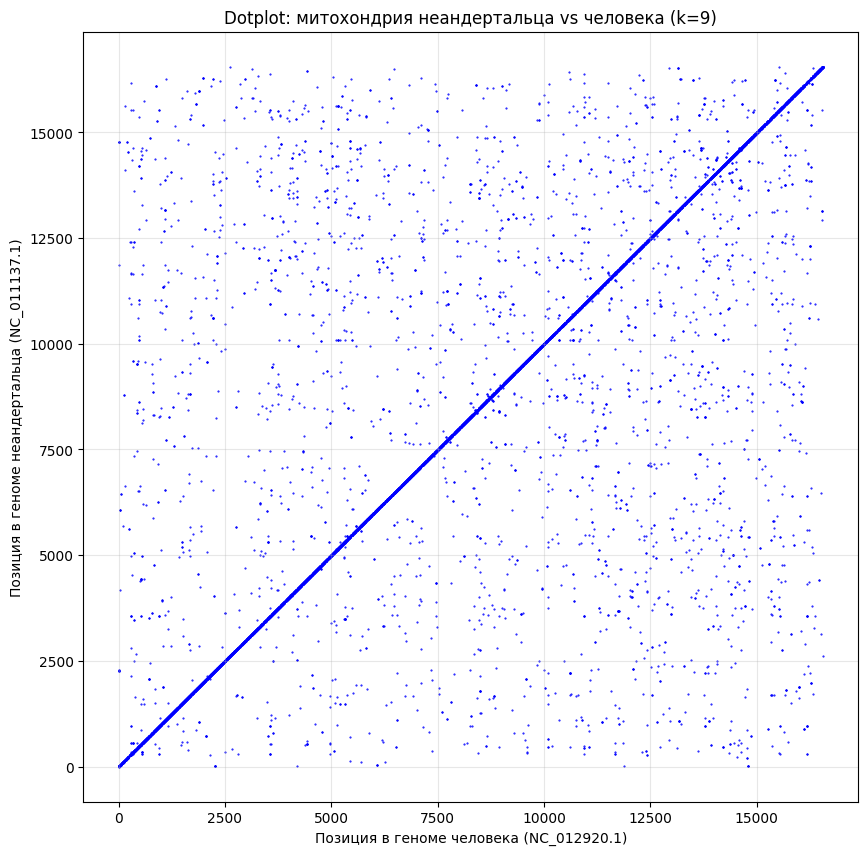


Анализ: На графике видна чёткая главная диагональ, что говорит о высокой степени сходства. Крупные инверсии, делеции или дупликации отсутствуют. Это подтверждает близкое родство митохондриальных геномов неандертальца и современного человека.


In [33]:
import os
import urllib.request
from Bio import SeqIO
import matplotlib.pyplot as plt


url_neand = "https://www.ncbi.nlm.nih.gov/sviewer/viewer.fcgi?db=nuccore&id=NC_011137.1&report=fasta&retmode=text"
url_human = "https://www.ncbi.nlm.nih.gov/sviewer/viewer.fcgi?db=nuccore&id=NC_012920.1&report=fasta&retmode=text"

filenames = {
    "neanderthal.fa": url_neand,
    "human.fa": url_human
}

for fname, url in filenames.items():
    if not os.path.exists(fname):
        urllib.request.urlretrieve(url, fname)
        print(f"Скачан: {fname}")

# Чтение последовательностей
neand_seq = str(SeqIO.read("neanderthal.fa", "fasta").seq).upper()
human_seq = str(SeqIO.read("human.fa", "fasta").seq).upper()
print(f"Длина митохондрии неандертальца: {len(neand_seq)}")
print(f"Длина митохондрии человека: {len(human_seq)}")

# Построение DotPlot (k=9)
k = 9
matches = []
for i in range(len(neand_seq)-k+1):
    kmer = neand_seq[i:i+k]
    start = 0
    while True:
        pos = human_seq.find(kmer, start)
        if pos == -1:
            break
        matches.append((i, pos))
        start = pos + 1

# Визуализация
x = [m[1] for m in matches]
y = [m[0] for m in matches]
plt.figure(figsize=(10,10))
plt.scatter(x, y, s=1, c='blue', marker='.')
plt.title("Dotplot: митохондрия неандертальца vs человека (k=9)")
plt.xlabel("Позиция в геноме человека (NC_012920.1)")
plt.ylabel("Позиция в геноме неандертальца (NC_011137.1)")
plt.grid(alpha=0.3)
plt.show()

print("\nАнализ: На графике видна чёткая главная диагональ, что говорит о высокой степени"
      " сходства. Крупные инверсии, делеции или дупликации отсутствуют."
      " Это подтверждает близкое родство митохондриальных геномов неандертальца и современного человека.")